In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as mlt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [2]:
df=pd.read_csv(r"C:\Users\SALMAN PC\Downloads\archive (1)\insurance.csv")

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
df.shape

(1338, 7)

In [7]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(1)

In [9]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


<Axes: xlabel='age', ylabel='charges'>

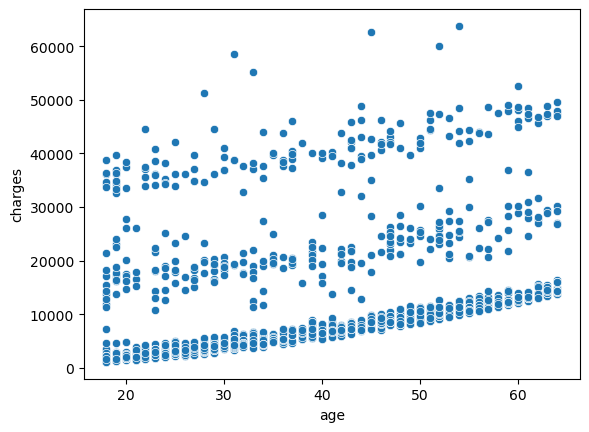

In [10]:
sns.scatterplot(data=df,x="age",y="charges")

<Axes: xlabel='bmi', ylabel='charges'>

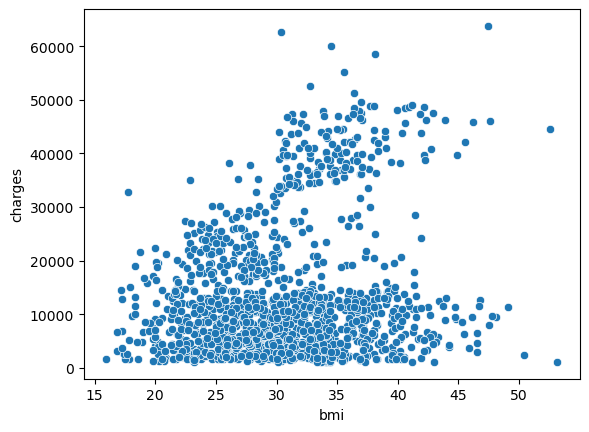

In [11]:
sns.scatterplot(data=df,x="bmi",y="charges")

<Axes: xlabel='sex', ylabel='charges'>

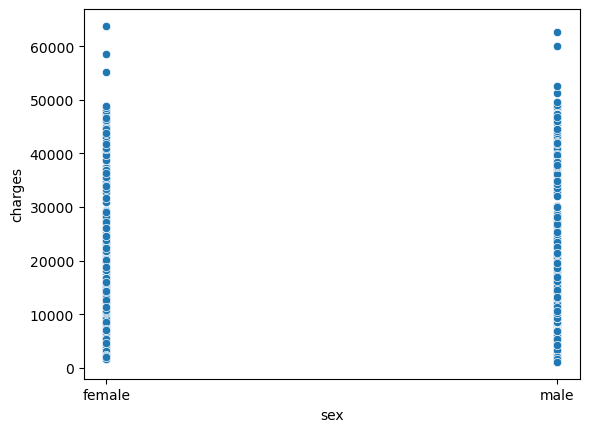

In [12]:
sns.scatterplot(data=df,x="sex",y="charges")

<Axes: xlabel='children', ylabel='charges'>

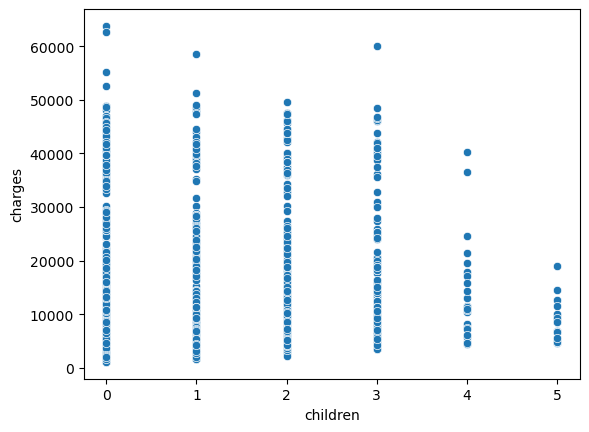

In [13]:
sns.scatterplot(data=df,x="children",y="charges")

<Axes: xlabel='smoker', ylabel='charges'>

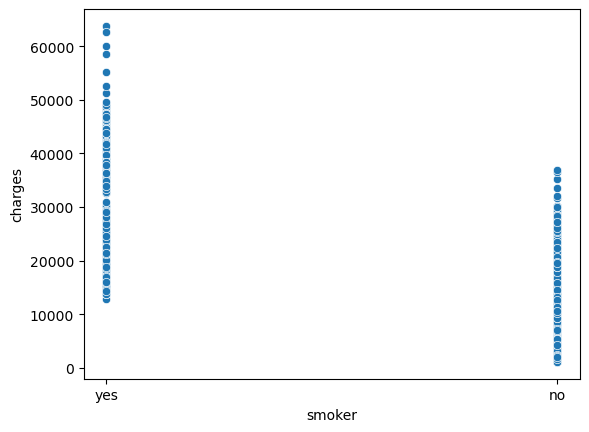

In [14]:
sns.scatterplot(data=df,x="smoker",y="charges")

<Axes: xlabel='region', ylabel='charges'>

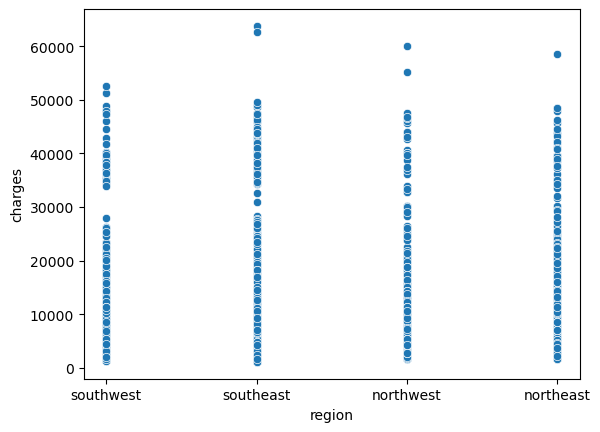

In [15]:
sns.scatterplot(data=df,x="region",y="charges")

In [16]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [17]:
# now doing the hotencoding
x=df.drop("charges",axis=1)
y=df["charges"]

In [18]:
num=["age","bmi","children"]
catogorical=["sex","smoker","region"]

In [19]:
preprocessor = ColumnTransformer(transformers=[('num2',StandardScaler(),num),
       ('cat2',OneHotEncoder(drop='first',sparse_output=False),catogorical)
                                      ])

In [20]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [21]:
x_train_s=preprocessor.fit_transform(x_train)
x_test_s=preprocessor.transform(x_test)

In [22]:
model=LinearRegression()

In [23]:
model.fit(x_train_s,y_train)

LinearRegression()

In [24]:
pred=model.predict(x_test_s)

In [25]:
pred

array([ 8969.55027444,  7068.74744287, 36858.41091155,  9454.67850053,
       26973.17345656, 10864.11316424,   170.28084136, 16903.45028662,
        1092.43093614, 11218.34318352, 28101.68455267,  9377.73460205,
        5263.0595179 , 38416.04221107, 40255.82339284, 37098.25353123,
       15240.39392306, 35912.88264434,  9112.52398703, 31461.92108909,
        3847.68845883, 10130.12001517,  2370.54189389,  7140.21550828,
       11301.76782638, 12961.65366224, 14509.47251876,  6159.8976107 ,
        9963.85857263,  2177.85718217,  9115.93673493, 13073.68932159,
        4561.82376202,  3408.20756033,  4459.81359745, 13032.06505076,
        1979.99357292,  8813.28303302, 33271.29124448, 32585.51583927,
        3908.76090964,  4326.10774721, 14142.81326533, 11423.45494846,
        8774.13955311, 12097.28051001,  5281.57353499,  3150.5596042 ,
       35494.46461214,  9150.1124786 , 15836.84575621,  2343.57470069,
       12364.78414194,  1482.29488266, 13389.06105161, 12573.57395972,
      

In [27]:
r2_1 = r2_score(y_test, pred)
rmse_1 = np.sqrt(mean_squared_error(y_test, pred))
# mae_1 = mean_absolute_error(y_test, pred)

In [30]:
(r2_1)*100

78.35929767120722

In [33]:
poly=PolynomialFeatures(degree=2,include_bias=False)

In [35]:
x_train_poly=poly.fit_transform(x_train_s)
x_test_poly=poly.transform(x_test_s)

In [37]:
model2=LinearRegression()

In [38]:
model2.fit(x_train_poly,y_train)

LinearRegression()

In [40]:
pre_2=model2.predict(x_test_poly)

In [42]:
pre_2

array([11215.72133573,  6055.22653741, 33306.27444924, 10833.80112228,
       29082.43036144,  4258.24448939,  2803.16158684, 16037.07690313,
        4106.52868351, 12147.42558983, 20028.8757701 ,  9337.04044735,
        5818.84568409, 49497.37304858, 53113.5937285 , 45430.5761478 ,
       10241.19985184, 41674.61188463, 10080.8431564 , 25746.27231737,
        3457.33375943,  8194.71496457,  1959.28733509,  5462.27995185,
       12888.82915338, 12399.24089824, 14240.76160301,  8094.46623135,
       11950.74969399,  3186.67935961,  8780.78145851, 12491.65988454,
        3133.60249208,  7079.81057509,  3649.85032867,  8703.71386282,
        3897.23030936,  8673.9286432 , 24874.96813275, 36937.9714649 ,
        5240.2192649 ,  4809.39595947, 13046.1202492 , 13141.06268642,
        6759.25565275, 14046.51840738,  6466.13078208,  5328.54012533,
       39961.1279037 ,  6012.40028143, 15370.44162854,  4006.64042398,
        8034.09424184,  3238.70492687, 13238.76583917, 11931.08398122,
      

In [53]:
r2_3 = r2_score(y_test, pre_2)
rmse_3 = np.sqrt(mean_squared_error(y_test, pre_2))

In [57]:
print(f"the accuracy is {r2_3}")
print(f"mean squared error is {rmse_3}")

the accuracy is 0.866583090316484
mean squared error is 4551.1323852331925
